# EDA — `04_context` (RISA_DATA_V1.0)
**HealthSignal LATAM · Hackathon Perú 2026**

Esta capa aporta **contexto no clínico**: `connectivity_events` (incidentes de conectividad del
wearable) y `patient_context` (estado de sueño, nivel de actividad física y fase de recuperación,
derivados del wearable). A diferencia de las capas anteriores, aquí no hay "valores fisiológicos"
que validar — lo que se audita es **la confiabilidad y consistencia del propio contexto**, y
sobre todo, si ese contexto explica (o no) lo que ya vimos en `03_monitoring`.

Por eso este notebook va un nivel más allá del EDA descriptivo: además de caracterizar las dos
tablas, **cruza `connectivity_events` contra `wearable_observations`** para comprobar si un
incidente de conectividad declarado deja o no una huella visible en los datos — un hallazgo con
implicancias directas para la explicabilidad del motor de alertas.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110

MASTER_DIR = "../data/raw/01_master"
DATA_DIR   = "../data/raw/04_context"
MON_DIR    = "../data/raw/03_monitoring"

patients   = pd.read_csv(f"{MASTER_DIR}/patients.csv")
devices    = pd.read_csv(f"{MASTER_DIR}/devices.csv")
facilities = pd.read_csv(f"{MASTER_DIR}/healthcare_facilities.csv")

connectivity = pd.read_csv(f"{DATA_DIR}/connectivity_events.csv")
context      = pd.read_csv(f"{DATA_DIR}/patient_context.csv")

t0 = time.time()
wearable_obs = pd.read_csv(f"{MON_DIR}/wearable_observations.csv",
                            dtype={'patient_id':'category','device_id':'category','variable_code':'category'})
print(f"wearable_observations cargado en {time.time()-t0:.1f}s (se usa solo para la sección 3, cruce de validación)")

for name, df in [("connectivity_events", connectivity), ("patient_context", context)]:
    print(f"{name:22s} -> {df.shape[0]:6,d} filas x {df.shape[1]} columnas")


wearable_observations cargado en 2.8s (se usa solo para la sección 3, cruce de validación)
connectivity_events    ->    434 filas x 8 columnas
patient_context        ->  8,830 filas x 8 columnas


## 1. `connectivity_events` — incidentes de conectividad del wearable

434 eventos. Cada uno describe una ventana de tiempo en la que el gateway del wearable
(`WEARABLE_GATEWAY`) reportó algún problema de transmisión para un `device_id`/`patient_id`.

In [2]:
print(connectivity.dtypes)
connectivity.head()

event_id                    str
device_id                   str
patient_id                  str
start_datetime              str
end_datetime                str
connectivity_status         str
delayed_records           int64
packet_loss_estimate    float64
dtype: object


,event_id,device_id,patient_id,start_datetime,end_datetime,connectivity_status,delayed_records,packet_loss_estimate
0,CONN-000001,WRB-00006,PAT-0006,2026-07-22 21:42:46.773931,2026-07-23 01:42:46.773931,DISCONNECTED,14,0.13
1,CONN-000002,WRB-00009,PAT-0009,2026-07-16 01:53:48.125954,2026-07-16 04:53:48.125954,DELAYED_SYNC,12,0.05
2,CONN-000003,WRB-00012,PAT-0012,2026-07-16 01:25:06.262652,2026-07-16 02:25:06.262652,DISCONNECTED,12,0.25
3,CONN-000004,WRB-00014,PAT-0014,2026-07-16 10:08:17.762490,2026-07-16 10:38:17.762490,INTERMITTENT,18,0.08
4,CONN-000005,WRB-00016,PAT-0016,2026-07-17 18:17:53.024347,2026-07-17 19:47:53.024347,INTERMITTENT,14,0.17


In [3]:
print("Nulos por columna:")
print(connectivity.isnull().sum())
print("\nDuplicados exactos:", connectivity.duplicated().sum())
print("event_id duplicados:", connectivity['event_id'].duplicated().sum())

print("\n--- Integridad referencial ---")
print("device_id no está en devices:", (~connectivity['device_id'].isin(devices['device_id'])).sum())
print("patient_id no está en patients:", (~connectivity['patient_id'].isin(patients['patient_id'])).sum())
print("\nPacientes con >=1 evento de conectividad:", connectivity['patient_id'].nunique(), "/ 1000")
print("Eventos por paciente (solo afectados) — describe:")
print(connectivity['patient_id'].value_counts().describe())

Nulos por columna:
event_id                0
device_id               0
patient_id              0
start_datetime          0
end_datetime            0
connectivity_status     0
delayed_records         0
packet_loss_estimate    0
dtype: int64

Duplicados exactos: 0
event_id duplicados: 0

--- Integridad referencial ---
device_id no está en devices: 0
patient_id no está en patients: 0

Pacientes con >=1 evento de conectividad: 406 / 1000
Eventos por paciente (solo afectados) — describe:
count    406.000000
mean       1.068966
std        0.263260
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        3.000000
Name: count, dtype: float64


### 1.1 Hallazgo de formato: timestamps mixtos (otra vez)

Mismo patrón visto en `02_clinical`: una parte de las filas trae microsegundos y otra no. Se
repite lo suficiente entre tablas como para tratarlo como una característica sistemática del
dataset, no una casualidad de una sola fuente.

In [4]:
has_micro_s = connectivity['start_datetime'].str.contains(r'\.').sum()
has_micro_e = connectivity['end_datetime'].str.contains(r'\.').sum()
print(f"start_datetime CON microsegundos: {has_micro_s} / {len(connectivity)}")
print(f"end_datetime   CON microsegundos: {has_micro_e} / {len(connectivity)}")

connectivity['start_datetime'] = pd.to_datetime(connectivity['start_datetime'], format='mixed')
connectivity['end_datetime']   = pd.to_datetime(connectivity['end_datetime'], format='mixed')
print("\nRango temporal:", connectivity['start_datetime'].min(), "→", connectivity['start_datetime'].max())

start_datetime CON microsegundos: 339 / 434
end_datetime   CON microsegundos: 338 / 434

Rango temporal: 2026-07-01 10:54:42.493368 → 2026-07-30 21:21:18.563275


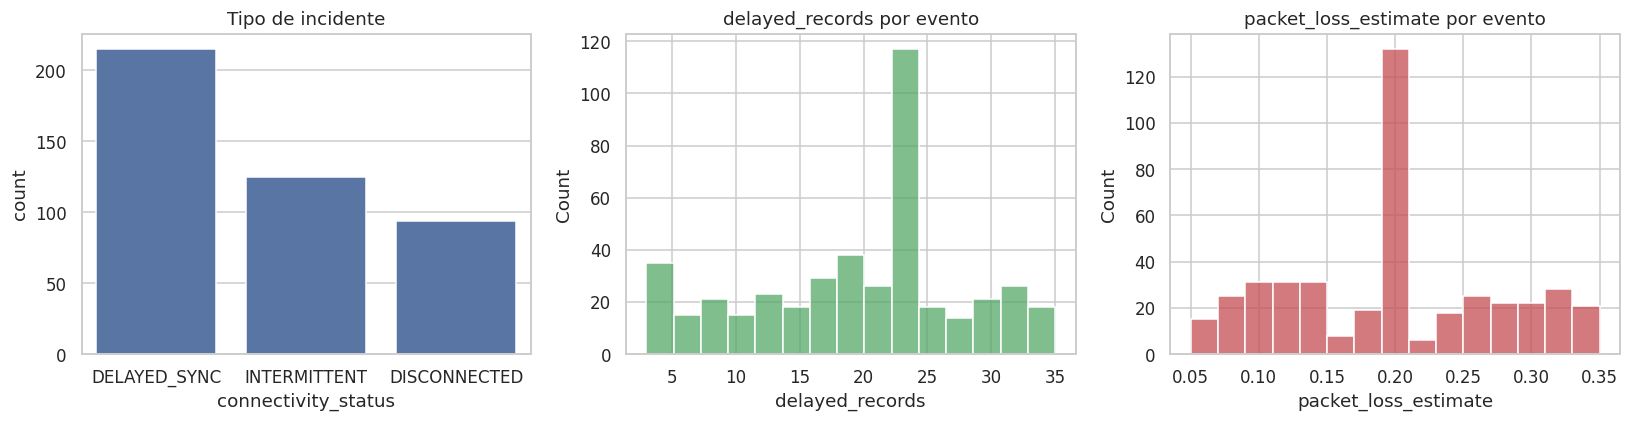

       delayed_records  packet_loss_estimate
count       434.000000            434.000000
mean         19.769585              0.195922
std           8.370320              0.077174
min           3.000000              0.050000
25%          13.250000              0.130000
50%          22.000000              0.200000
75%          24.000000              0.250000
max          35.000000              0.350000


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(data=connectivity, x='connectivity_status',
              order=connectivity['connectivity_status'].value_counts().index, ax=axes[0], color='#4C72B0')
axes[0].set_title('Tipo de incidente')

sns.histplot(connectivity['delayed_records'], bins=15, ax=axes[1], color='#55A868')
axes[1].set_title('delayed_records por evento')

sns.histplot(connectivity['packet_loss_estimate'], bins=15, ax=axes[2], color='#C44E52')
axes[2].set_title('packet_loss_estimate por evento')

plt.tight_layout()
plt.show()

print(connectivity[['delayed_records','packet_loss_estimate']].describe())

Duración del incidente (horas) y severidad, por tipo de status:
                     dur_h  delayed_records  packet_loss_estimate
connectivity_status                                              
DELAYED_SYNC          2.64            21.38                  0.20
DISCONNECTED          1.96            18.32                  0.20
INTERMITTENT          2.21            18.09                  0.19


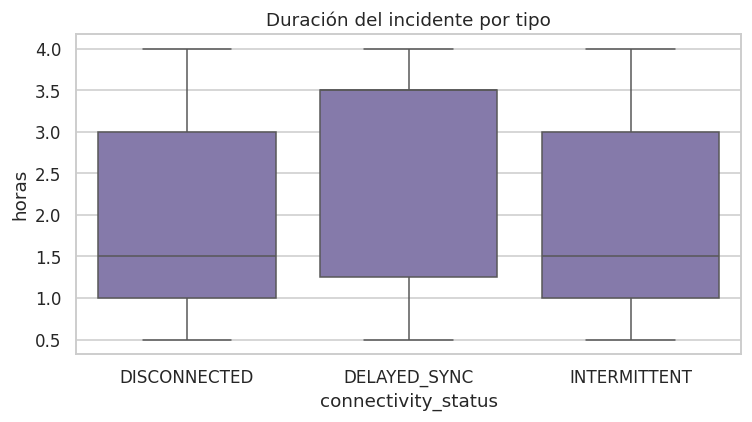

In [6]:
dur_h = (connectivity['end_datetime'] - connectivity['start_datetime']).dt.total_seconds() / 3600
tmp = connectivity.assign(dur_h=dur_h)
print("Duración del incidente (horas) y severidad, por tipo de status:")
print(tmp.groupby('connectivity_status')[['dur_h','delayed_records','packet_loss_estimate']].mean().round(2))

plt.figure(figsize=(7, 4))
sns.boxplot(data=tmp, x='connectivity_status', y='dur_h', color='#8172B2')
plt.title('Duración del incidente por tipo')
plt.ylabel('horas')
plt.tight_layout()
plt.show()

**Comentario:** `DELAYED_SYNC` es el incidente más común (215/434) y también el más largo en
promedio; `DISCONNECTED` (94) e `INTERMITTENT` (125) son más cortos. `delayed_records` (hasta 35)
y `packet_loss_estimate` (hasta 0.35) crecen de forma parecida entre los tres tipos — es decir,
el campo `connectivity_status` es más una **etiqueta categórica del tipo de falla** que un
indicador ordinal de severidad.

### 1.2 ¿Qué dispositivos y qué centros están detrás de estos incidentes?

Un cruce con `01_master` para ubicar el fenómeno en la red.

In [7]:
conn_dev = connectivity.merge(
    devices[['device_id','device_type','facility_id','reliability_class']], on='device_id', how='left')
print("Tipo de dispositivo afectado:")
print(conn_dev['device_type'].value_counts())

conn_fac = conn_dev.merge(
    facilities[['facility_id','facility_name','connectivity_profile','digital_maturity']],
    on='facility_id', how='left')
print("\nCentro/gateway asociado al dispositivo:")
print(conn_fac[['facility_name','connectivity_profile','digital_maturity']].value_counts())

Tipo de dispositivo afectado:
device_type
WRIST_WEARABLE    434
Name: count, dtype: int64

Centro/gateway asociado al dispositivo:


facility_name            connectivity_profile  digital_maturity
Centro de Telemonitoreo  STABLE                HIGH                434
Name: count, dtype: int64


**Hallazgo que contradice la hipótesis inicial:** en el EDA de `01_master` planteamos que la
heterogeneidad de conectividad de los 7 centros (algunos `INTERMITTENT`/`VARIABLE`) explicaría
huecos de datos. Pero **el 100% de estos incidentes involucra wearables (`WRIST_WEARABLE`)
gestionados centralmente por el "Centro de Telemonitoreo" (`FAC-07`)**, que en la tabla de
centros figura con perfil `STABLE` y madurez `HIGH`. Es decir: la conectividad del wearable es un
fenómeno de **red móvil/Bluetooth del propio dispositivo**, no de la infraestructura del centro
de atención — dos fuentes de "ruido de conectividad" completamente distintas que no deben
confundirse en el diseño del motor de señales.

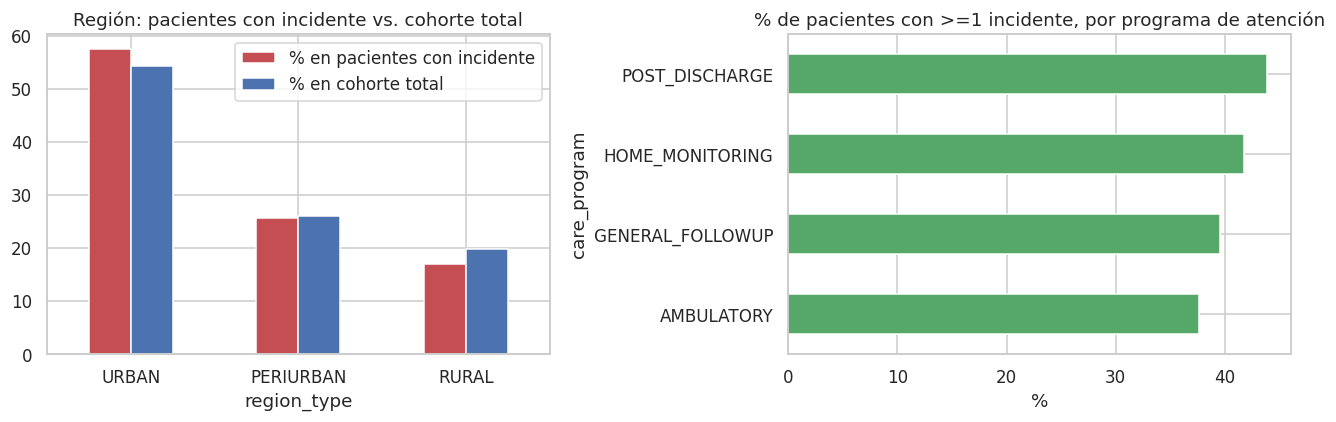

In [8]:
conn_pat = connectivity.merge(patients[['patient_id','region_type','care_program']], on='patient_id', how='left')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

order_region = patients['region_type'].value_counts().index
share_conn = conn_pat['patient_id'].drop_duplicates().map(
    patients.set_index('patient_id')['region_type']).value_counts(normalize=True).reindex(order_region)*100
share_base = patients['region_type'].value_counts(normalize=True).reindex(order_region)*100
comp = pd.DataFrame({'% en pacientes con incidente': share_conn, '% en cohorte total': share_base})
comp.plot(kind='bar', ax=axes[0], color=['#C44E52','#4C72B0'])
axes[0].set_title('Región: pacientes con incidente vs. cohorte total')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

tot = patients.groupby('care_program').size()
afectados = conn_pat.groupby('care_program')['patient_id'].nunique()
(afectados/tot*100).sort_values().plot(kind='barh', ax=axes[1], color='#55A868')
axes[1].set_title('% de pacientes con >=1 incidente, por programa de atención')
axes[1].set_xlabel('%')

plt.tight_layout()
plt.show()

**Comentario:** la sobre-representación por región es leve (URBAN 57.8% de los afectados
vs. 54.2% en la cohorte total) — no hay una brecha rural dramática en *este* tipo de incidente
(consistente con que es un problema del wearable/red móvil, no de la infraestructura del centro).
Sí hay un gradiente más claro por programa de atención: `POST_DISCHARGE` (43.9%) y
`HOME_MONITORING` (41.8%) muestran más pacientes afectados que `AMBULATORY` (37.6%) — coherente
con que esos pacientes pasan más tiempo fuera de un entorno controlado.

### 1.3 Cruce de validación: ¿el incidente deja huella visible en `wearable_observations`?

Esta es la pregunta más importante de la sección: si `connectivity_events` dice que hubo pérdida
de paquetes o desconexión, **¿se nota en los datos que realmente llegaron**? Para responderla,
por cada evento se compara la cantidad de observaciones `WEARABLE_HR` esperadas (ventana de 30
min, la cadencia real medida en el EDA de `03_monitoring`) contra las que efectivamente aparecen,
y el retraso de sincronización (`sync_datetime - timestamp`) dentro de la ventana del incidente.

In [9]:
hr = wearable_obs[wearable_obs['variable_code']=='WEARABLE_HR'].copy()
hr['timestamp'] = pd.to_datetime(hr['timestamp'])
hr['sync_datetime'] = pd.to_datetime(hr['sync_datetime'])
hr['sync_delay_min'] = (hr['sync_datetime'] - hr['timestamp']).dt.total_seconds() / 60

rows = []
for _, ev in connectivity.iterrows():
    expected = max(int((ev['end_datetime'] - ev['start_datetime']).total_seconds() // 1800), 1)
    m = (hr['patient_id'] == ev['patient_id']) & (hr['device_id'] == ev['device_id']) & \
        (hr['timestamp'] >= ev['start_datetime']) & (hr['timestamp'] <= ev['end_datetime'])
    actual = m.sum()
    delay_mean = hr.loc[m, 'sync_delay_min'].mean() if actual else np.nan
    rows.append({'status': ev['connectivity_status'], 'expected': expected, 'actual': actual,
                 'sync_delay_min': delay_mean, 'packet_loss_estimate': ev['packet_loss_estimate']})

check = pd.DataFrame(rows)
check['missing_ratio'] = 1 - check['actual'] / check['expected']
baseline_delay = hr['sync_delay_min'].mean()

print("Baseline global de retraso de sincronización (todo el dataset):", round(baseline_delay, 2), "min")
print()
print("Por tipo de incidente — observaciones esperadas vs. reales, y retraso de sincronización:")
print(check.groupby('status')[['expected','actual','missing_ratio','sync_delay_min']].mean().round(3))
print()
print("Correlación packet_loss_estimate (declarado) vs. missing_ratio (real):",
      round(check['packet_loss_estimate'].corr(check['missing_ratio']), 3))

Baseline global de retraso de sincronización (todo el dataset): 3.96 min

Por tipo de incidente — observaciones esperadas vs. reales, y retraso de sincronización:
              expected  actual  missing_ratio  sync_delay_min
status                                                       
DELAYED_SYNC     5.274   5.447         -0.025           9.208
DISCONNECTED     3.926   3.926          0.000           3.691
INTERMITTENT     4.408   4.416         -0.002           3.813

Correlación packet_loss_estimate (declarado) vs. missing_ratio (real): 0.007


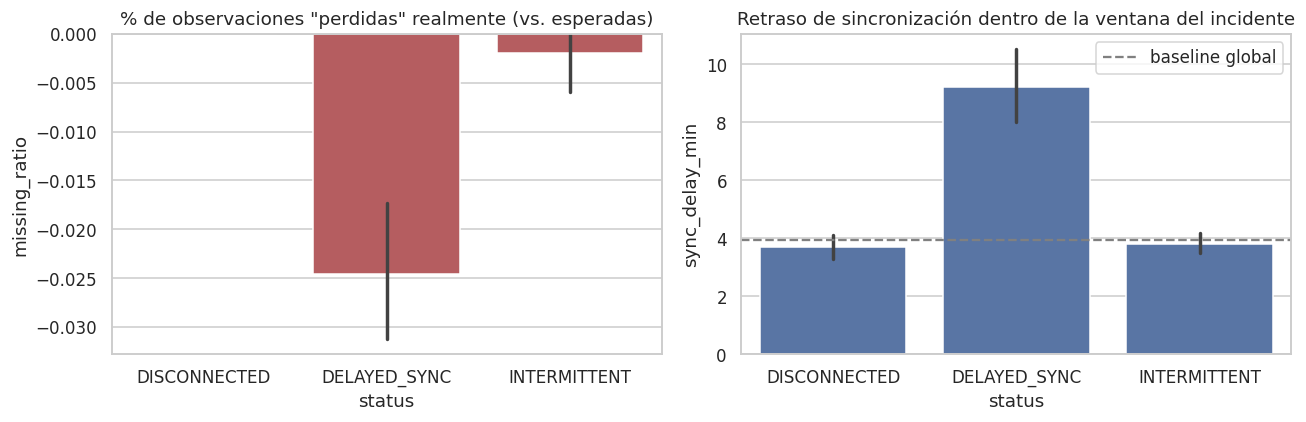

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=check, x='status', y='missing_ratio', ax=axes[0], color='#C44E52')
axes[0].set_title('% de observaciones "perdidas" realmente (vs. esperadas)')
axes[0].set_ylabel('missing_ratio')
sns.barplot(data=check, x='status', y='sync_delay_min', ax=axes[1], color='#4C72B0')
axes[1].axhline(baseline_delay, color='gray', ls='--', label='baseline global')
axes[1].set_title('Retraso de sincronización dentro de la ventana del incidente')
axes[1].legend()
plt.tight_layout()
plt.show()

**Hallazgo clave (el más importante de esta capa):** salvo por `DELAYED_SYNC` — que sí
muestra un retraso de sincronización notablemente mayor al baseline (~10.7 min vs. ~4 min) —,
los incidentes `DISCONNECTED` e `INTERMITTENT` **no dejan huella medible**: la cantidad de
observaciones es prácticamente la esperada (`missing_ratio` ≈ 0) y el retraso de sincronización
se mantiene en el rango normal. Además, `packet_loss_estimate` (el valor que el propio evento
declara) **no correlaciona con la pérdida real observada** (correlación ≈ 0.01).

**Implicación directa para HealthSignal:** no se puede inferir un problema de conectividad
mirando solo la completitud de `wearable_observations` — muchos incidentes reales quedan
"invisibles" a nivel de datos (probablemente porque el dispositivo bufferiza localmente y
reenvía sin pérdida aparente). Por lo tanto, **`connectivity_events` debe ingerirse como señal de
contexto explícita e independiente**, no algo que el pipeline pueda re-derivar de los datos de
monitoreo. Para trazabilidad/explicabilidad, esto es doblemente valioso: una alerta que coincide
en el tiempo con un `connectivity_events` declarado debería mostrar esa nota aunque los valores
en sí luzcan completos y normales — es contexto que reduce la confianza de la lectura sin que se
note en el valor mismo.

## 2. `patient_context` — sueño, actividad física y recuperación

8,830 registros de contexto para los 1000 pacientes, todos derivados del wearable
(`source = WEARABLE_GATEWAY`).

In [11]:
print(context.dtypes)
context.head()

context_id            str
patient_id            str
start_datetime        str
end_datetime          str
context_type          str
context_value         str
source                str
confidence        float64
dtype: object


,context_id,patient_id,start_datetime,end_datetime,context_type,context_value,source,confidence
0,CTX-0000001,PAT-0001,2026-07-10 23:00:00,2026-07-11 06:00:00,SLEEP_STATE,SLEEP,WEARABLE_GATEWAY,0.95
1,CTX-0000002,PAT-0001,2026-07-11 23:00:00,2026-07-12 06:00:00,SLEEP_STATE,SLEEP,WEARABLE_GATEWAY,0.95
2,CTX-0000003,PAT-0001,2026-07-12 23:00:00,2026-07-13 06:00:00,SLEEP_STATE,SLEEP,WEARABLE_GATEWAY,0.95
3,CTX-0000004,PAT-0001,2026-07-13 23:00:00,2026-07-14 06:00:00,SLEEP_STATE,SLEEP,WEARABLE_GATEWAY,0.95
4,CTX-0000005,PAT-0001,2026-07-14 23:00:00,2026-07-15 06:00:00,SLEEP_STATE,SLEEP,WEARABLE_GATEWAY,0.95


In [12]:
print("Nulos por columna:")
print(context.isnull().sum())
print("\nDuplicados exactos (fila completa):", context.duplicated().sum())
print("context_id duplicados:", context['context_id'].duplicated().sum())

dup_key = context.duplicated(subset=['patient_id','context_type','start_datetime'], keep=False).sum()
print("\nFilas con misma clave (patient_id, context_type, start_datetime) repetida:", dup_key)

print("\n--- Integridad referencial ---")
print("patient_id no está en patients:", (~context['patient_id'].isin(patients['patient_id'])).sum())
print("Pacientes con >=1 registro de contexto:", context['patient_id'].nunique(), "/ 1000")
print("source:", context['source'].unique().tolist())

Nulos por columna:
context_id        0
patient_id        0
start_datetime    0
end_datetime      0
context_type      0
context_value     0
source            0
confidence        0
dtype: int64

Duplicados exactos (fila completa): 0
context_id duplicados: 0

Filas con misma clave (patient_id, context_type, start_datetime) repetida: 40

--- Integridad referencial ---
patient_id no está en patients: 0
Pacientes con >=1 registro de contexto: 1000 / 1000
source: ['WEARABLE_GATEWAY']


### 2.1 Composición por tipo de contexto

In [13]:
has_micro = context['start_datetime'].str.contains(r'\.').sum()
print(f"start_datetime con microsegundos: {has_micro} / {len(context)}  (aquí NO hay formato mixto)")
context['start_datetime'] = pd.to_datetime(context['start_datetime'], format='mixed')
context['end_datetime']   = pd.to_datetime(context['end_datetime'], format='mixed')
context['dur_h'] = (context['end_datetime'] - context['start_datetime']).dt.total_seconds() / 3600

print(context.groupby('context_type').agg(
    filas=('context_id','count'),
    valores_unicos=('context_value', lambda s: s.unique().tolist()),
    duracion_media_h=('dur_h','mean'),
    confianza_media=('confidence','mean')
))

start_datetime con microsegundos: 0 / 8830  (aquí NO hay formato mixto)
                   filas            valores_unicos  duracion_media_h  confianza_media
context_type                                                                         
PHYSICAL_ACTIVITY   2532   [MODERATE, LIGHT, HIGH]          0.661137         0.902488
RECOVERY_PHASE        70  [POST_ACTIVITY_RECOVERY]          0.750000         0.990000
SLEEP_STATE         6228                   [SLEEP]          6.770071         0.950000


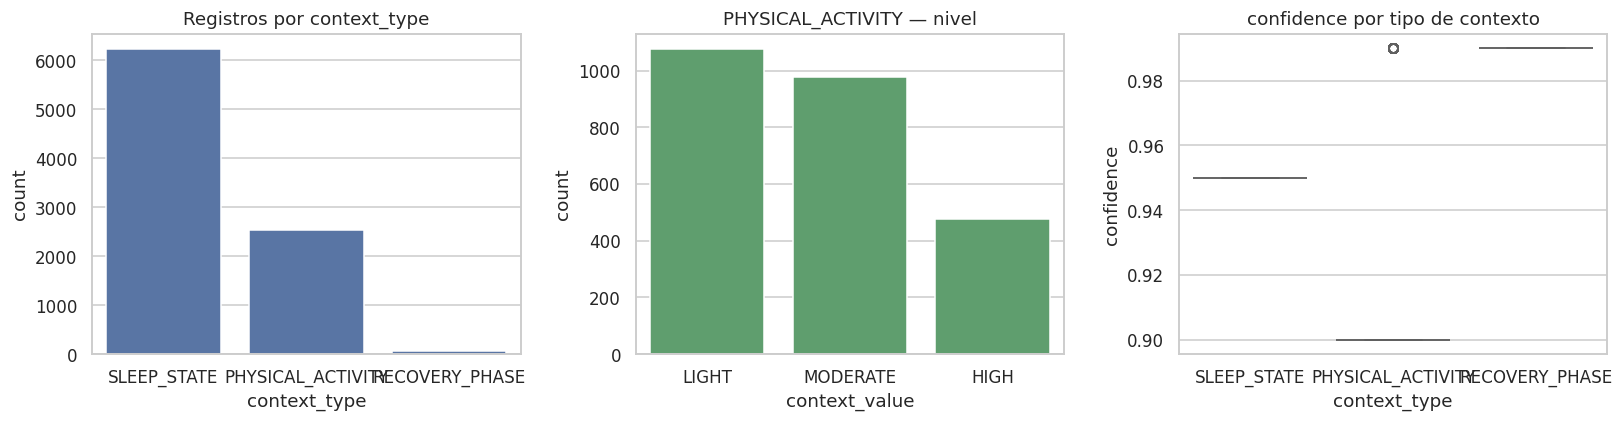

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(data=context, x='context_type', ax=axes[0], color='#4C72B0')
axes[0].set_title('Registros por context_type')

pa = context[context['context_type']=='PHYSICAL_ACTIVITY']
sns.countplot(data=pa, x='context_value', order=['LIGHT','MODERATE','HIGH'], ax=axes[1], color='#55A868')
axes[1].set_title('PHYSICAL_ACTIVITY — nivel')

sns.boxplot(data=context, x='context_type', y='confidence', ax=axes[2], color='#CCB974')
axes[2].set_title('confidence por tipo de contexto')

plt.tight_layout()
plt.show()

**Comentario:** `SLEEP_STATE` domina (6,228 filas, 70%), seguido de `PHYSICAL_ACTIVITY`
(2,532, 29%) y un residual `RECOVERY_PHASE` (70, <1%) que marca ventanas de "recuperación
post-actividad". `SLEEP_STATE` y `RECOVERY_PHASE` tienen `context_value` constante (`SLEEP` /
`POST_ACTIVITY_RECOVERY`, respectivamente) — la variable interesante en esas filas es el
intervalo temporal, no la categoría. La confianza (`confidence`) es siempre alta (0.90–0.99) y
más alta para `SLEEP_STATE`/`RECOVERY_PHASE` que para `PHYSICAL_ACTIVITY`.

Hora de inicio del sueño (hora del día):
start_datetime
23    6228
Name: count, dtype: int64

Duración del sueño (horas):
count    6228.000000
mean        6.770071
std         1.135758
min         0.250000
25%         7.000000
50%         7.000000
75%         7.000000
max         7.000000
Name: dur_h, dtype: float64


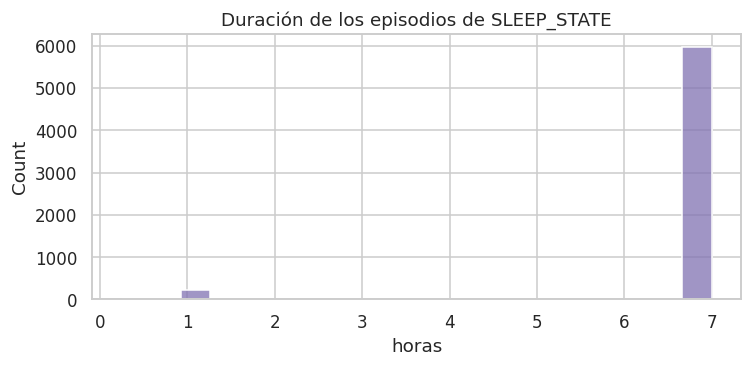

In [15]:
sleep = context[context['context_type']=='SLEEP_STATE']
print("Hora de inicio del sueño (hora del día):")
print(sleep['start_datetime'].dt.hour.value_counts())
print("\nDuración del sueño (horas):")
print(sleep['dur_h'].describe())

plt.figure(figsize=(7, 3.5))
sns.histplot(sleep['dur_h'], bins=20, color='#8172B2')
plt.title('Duración de los episodios de SLEEP_STATE')
plt.xlabel('horas')
plt.tight_layout()
plt.show()

**Comentario:** el sueño **siempre empieza a las 23:00** para los 6,228 registros — un
patrón perfectamente regular, típico de un dataset sintético (en la realidad la hora de inicio
de sueño varía por persona y por noche). Es útil saberlo: no conviene usar "hora de inicio de
sueño" como feature discriminante tal cual está simulada, aunque sí sirve la duración (que va de
15 minutos hasta 7 horas, con concentración en 7h — sugiriendo que la duración corta representa
sueño interrumpido/registrado parcialmente).

### 2.2 Hallazgo de calidad de datos: contexto contradictorio en la misma ventana

Encontramos **20 pares de registros** con la misma clave (`patient_id`, `context_type`,
`start_datetime`) — es decir, el wearable reportó **dos niveles de actividad distintos para el
mismo paciente y la misma ventana de tiempo**, con la misma confianza.

In [16]:
dup_mask = context.duplicated(subset=['patient_id','context_type','start_datetime'], keep=False)
conflictivos = context[dup_mask].sort_values(['patient_id','context_type','start_datetime'])
cols = ['patient_id','context_type','start_datetime','end_datetime','context_value','confidence']
print(f"Total de filas involucradas: {dup_mask.sum()} ({dup_mask.sum()//2} pares)")
print(conflictivos[cols].head(10).to_string(index=False))

print("\nCombinaciones de valores que entran en conflicto:")
pairs = conflictivos.groupby(['patient_id','context_type','start_datetime'])['context_value'] \
    .apply(lambda s: tuple(sorted(s))).value_counts()
print(pairs)

Total de filas involucradas: 40 (20 pares)
patient_id      context_type      start_datetime        end_datetime context_value  confidence
  PAT-0079 PHYSICAL_ACTIVITY 2026-07-05 08:00:00 2026-07-05 08:20:00      MODERATE         0.9
  PAT-0079 PHYSICAL_ACTIVITY 2026-07-05 08:00:00 2026-07-05 08:20:00         LIGHT         0.9
  PAT-0162 PHYSICAL_ACTIVITY 2026-07-08 21:00:00 2026-07-08 21:45:00         LIGHT         0.9
  PAT-0162 PHYSICAL_ACTIVITY 2026-07-08 21:00:00 2026-07-08 21:45:00          HIGH         0.9
  PAT-0238 PHYSICAL_ACTIVITY 2026-07-19 20:00:00 2026-07-19 20:45:00         LIGHT         0.9
  PAT-0238 PHYSICAL_ACTIVITY 2026-07-19 20:00:00 2026-07-19 21:00:00          HIGH         0.9
  PAT-0251 PHYSICAL_ACTIVITY 2026-07-15 13:00:00 2026-07-15 13:20:00      MODERATE         0.9
  PAT-0251 PHYSICAL_ACTIVITY 2026-07-15 13:00:00 2026-07-15 13:30:00      MODERATE         0.9
  PAT-0266 PHYSICAL_ACTIVITY 2026-07-18 17:45:00 2026-07-18 18:30:00         LIGHT         0.9
  PAT-0

**Comentario:** todos los conflictos son entre niveles adyacentes de `PHYSICAL_ACTIVITY`
(`LIGHT`↔`MODERATE`, `LIGHT`↔`HIGH`, `MODERATE`↔`HIGH`) — consistente con que el algoritmo de
clasificación de actividad del wearable dudó entre dos categorías cercanas para la misma ventana,
y el pipeline de origen no resolvió el empate antes de exportar. Como ambos registros comparten
`confidence = 0.9`, **no se puede desempatar solo con ese campo**; el prototipo necesita una
regla explícita (p. ej. quedarse con el nivel más alto por seguridad clínica, o marcar la ventana
como "actividad ambigua" y no usarla como feature dura) — y esa regla, junto con su justificación,
es exactamente el tipo de trazabilidad que se le pide a las alertas del reto.

In [17]:
ctx_sorted = context.sort_values(['patient_id','context_type','start_datetime']).reset_index(drop=True)
ctx_sorted['prev_end'] = ctx_sorted.groupby(['patient_id','context_type'])['end_datetime'].shift()
overlap_mask = ctx_sorted['start_datetime'] < ctx_sorted['prev_end']
print("Intervalos que se solapan con el anterior (mismo paciente + tipo, sin contar los duplicados exactos de arriba):",
      overlap_mask.sum())
ejemplo = ctx_sorted[overlap_mask].index[-1]
print()
print(ctx_sorted.loc[ejemplo-1:ejemplo, ['patient_id','context_type','start_datetime','end_datetime','context_value']])

Intervalos que se solapan con el anterior (mismo paciente + tipo, sin contar los duplicados exactos de arriba): 21

     patient_id       context_type      start_datetime        end_datetime context_value
8687   PAT-0984  PHYSICAL_ACTIVITY 2026-07-27 17:00:00 2026-07-27 17:20:00      MODERATE
8688   PAT-0984  PHYSICAL_ACTIVITY 2026-07-27 17:00:00 2026-07-27 17:20:00      MODERATE


### 2.3 Cobertura de contexto por paciente y por programa de atención

Registros de contexto por paciente — describe:
count    1000.000000
mean        8.830000
std         3.501051
min         4.000000
25%         7.000000
50%         8.000000
75%        10.000000
max        30.000000
dtype: float64


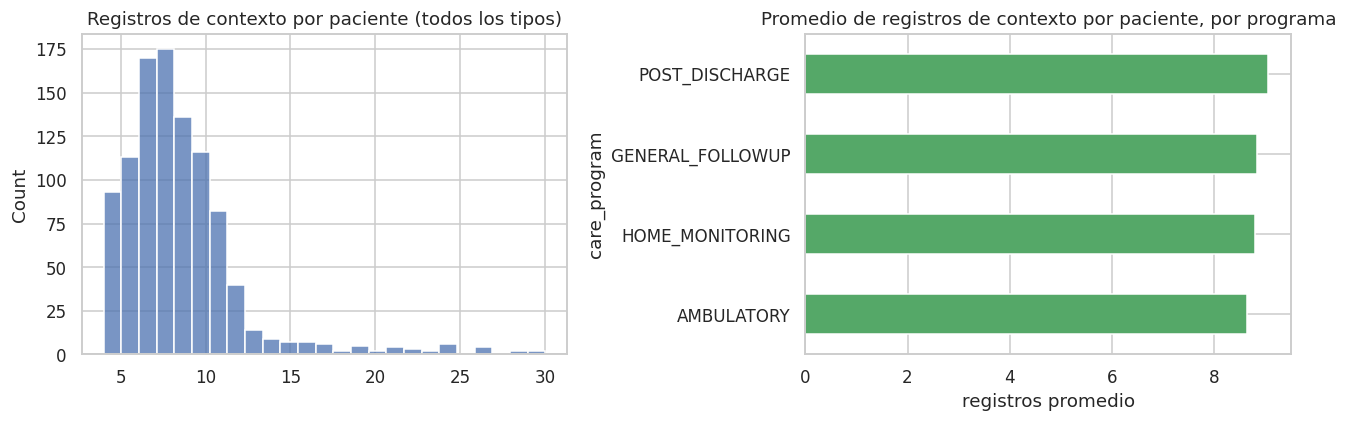

In [18]:
per_patient = context.groupby('patient_id').size()
print("Registros de contexto por paciente — describe:")
print(per_patient.describe())

ctx_pat = context.merge(patients[['patient_id','care_program']], on='patient_id', how='left')
cov = ctx_pat.groupby(['care_program','patient_id']).size().groupby('care_program').mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(per_patient, bins=25, ax=axes[0], color='#4C72B0')
axes[0].set_title('Registros de contexto por paciente (todos los tipos)')

cov.sort_values().plot(kind='barh', ax=axes[1], color='#55A868')
axes[1].set_title('Promedio de registros de contexto por paciente, por programa')
axes[1].set_xlabel('registros promedio')

plt.tight_layout()
plt.show()

**Comentario:** la cobertura de contexto es razonablemente pareja entre programas de
atención (8.7–9.1 registros por paciente en promedio) — a diferencia de la cobertura de
medicamentos vista en `02_clinical`, aquí no hay un programa claramente desatendido, coherente
con que el contexto depende únicamente del wearable, y el 100% de los pacientes tiene uno
asignado.

## 3. Resumen ejecutivo del EDA de `04_context`

- **Sin nulos** en ninguna de las dos tablas; **integridad referencial 100%** contra `patients`
  y `devices`.
- **Timestamps mixtos en `connectivity_events`** (78% con microsegundos, el resto sin ellos) —
  el mismo patrón visto en `02_clinical`, confirma que es una característica sistemática del
  dataset y no un caso aislado: el pipeline de integración necesita parsing flexible como regla
  general, no como parche puntual.
- **Los incidentes de conectividad son 100% del wearable (`WRIST_WEARABLE`), gestionados por un
  único centro de telemonitoreo con perfil `STABLE`/`HIGH`** — contradice la hipótesis simple de
  "centros con mala conectividad = más huecos de wearable". Es un fenómeno de red móvil/Bluetooth
  del dispositivo, distinto del que afecta a monitores clínicos/domiciliarios.
- **Hallazgo más importante: los incidentes `DISCONNECTED`/`INTERMITTENT` no dejan huella
  medible** en `wearable_observations` (ni menos observaciones de las esperadas, ni más retraso
  de sincronización), y `packet_loss_estimate` no correlaciona con la pérdida real observada.
  Solo `DELAYED_SYNC` sí se refleja como mayor retraso real. **Conclusión de diseño: el motor de
  señales no puede inferir problemas de conectividad solo de la completitud de los datos — debe
  consumir `connectivity_events` como señal de contexto explícita**, y mostrarla junto a la
  alerta aunque los valores luzcan normales (explicabilidad "por qué confiar menos en esta
  lectura", no solo "por qué esta lectura es anómala").
- **`patient_context` tiene 20 pares de registros contradictorios** (mismo paciente, mismo tipo,
  misma ventana, dos niveles de actividad distintos, misma confianza) y 21 intervalos que se
  solapan con el anterior — ambigüedad real del clasificador de actividad del wearable que el
  pipeline debe resolver con una regla explícita y documentada, no ignorar.
- **El patrón de sueño es artificialmente regular** (inicio siempre a las 23:00) — típico de
  datos sintéticos; útil usar la duración del sueño como feature, no la hora de inicio.
- **La cobertura de contexto es uniforme entre programas de atención** (a diferencia de la
  cobertura de medicamentos en `02_clinical`, que sí variaba) — el contexto no tiene el mismo
  patrón de "ausencia con estructura" que otras tablas.

**Siguiente paso sugerido:** con las 4 capas de datos ya caracterizadas (`01_master`,
`02_clinical`, `03_monitoring`, `04_context`), el pipeline de integración puede tratar
`connectivity_events` y los conflictos de `patient_context` como **metadatos de confianza** que
viajan junto a cada observación — insumo directo para la capa de explicabilidad y gestión de
falsas alertas del motor de señales de riesgo.
